# NLP Extraction Assessment: HICE Detection Engine

This notebook provides a comprehensive breakdown of the **Health-Impacting Conflict Events (HICE)** extraction logic. We will digest the keyword ontology, analyze the frequency of specific hits in the dataset, and explain how this aligns with **SDG 3 (Health)** and **SDG 16 (Peace & Justice)**.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import re
from collections import Counter

# Add root directory to path
sys.path.append(os.path.abspath('..'))
from src.processing import clean_conflict_data, extract_health_impacts

## 1. The Two-Layer Extraction Logic

Our extraction logic consists of two primary layers mapping to the UN Sustainable Development Goals (SDGs):

### Layer 1: SDG 3 (Good Health and Well-being)
This layer focuses on **Physical Infrastructure and Personnel**. It uses a Keyword Ontology (hospital, clinic, medic, etc.) to identify direct hits to the healthcare system.

### Layer 2: SDG 16 (Peace, Justice, and Strong Institutions)
This layer focuses on **Human Behavior and Violations**. It flags sub-event types that represent systemic threats to community well-being, such as **Abduction, Looting, and Sexual Violence**.

## 2. Validation Methodology (Manual Audit)

To ensure the automated system isn't just "guessing," we performed a rigorous manual audit:

1.  **Extraction**: Filtered the dataset using the curated ontology.
2.  **Randomized Sampling**: A subset of **200 events** was randomly selected from the pool.
3.  **Manual Review**: Each narrative was reviewed by a human to confirm if it represented a legitimate threat (True Positive).
4.  **Metric**: Precision = True Positives / 200.

/var/folders/5l/4p367cg93rx7b17m7w5g0pzc0000gp/T/ipykernel_4289/1680877881.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kw_df.values, y=kw_df.index, ax=ax1, palette='viridis')
/var/folders/5l/4p367cg93rx7b17m7w5g0pzc0000gp/T/ipykernel_4289/1680877881.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_df.values, y=ev_df.index, ax=ax2, palette='magma')


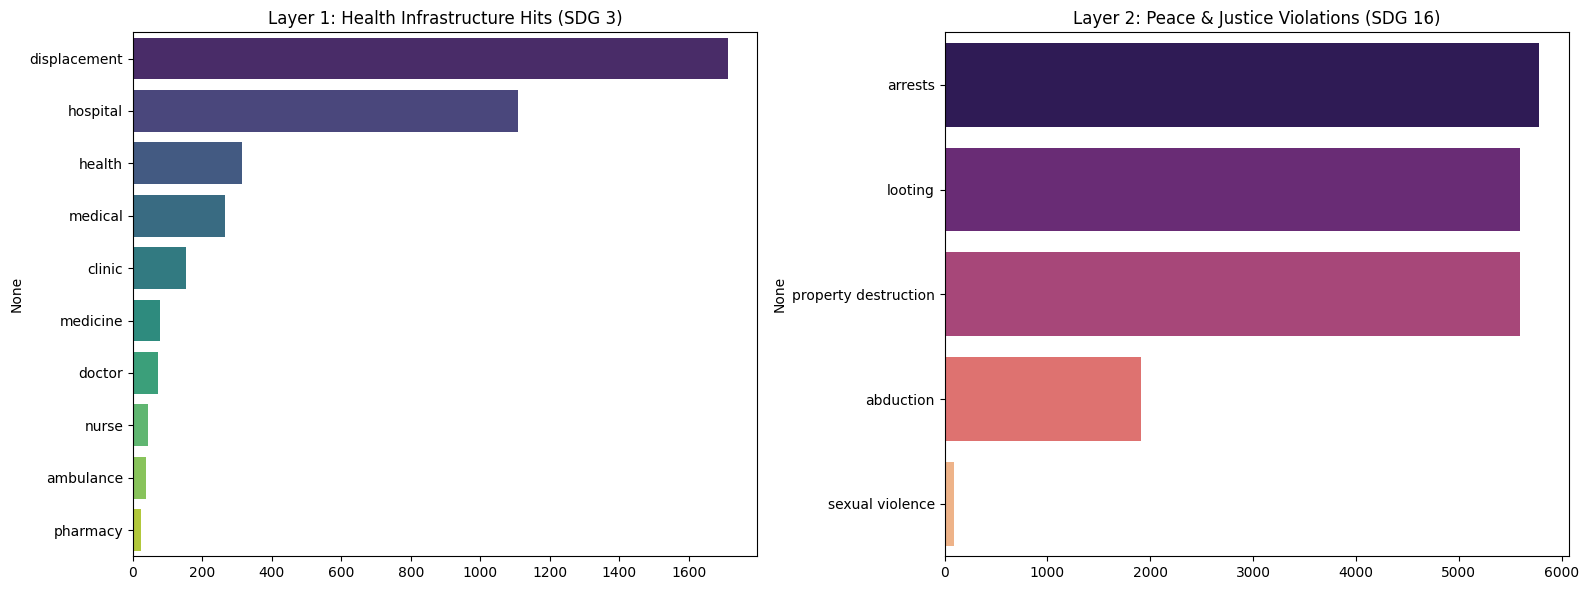

In [11]:
# Load and Digest
df = clean_conflict_data(pd.read_csv('../raw_data_output.csv'))

health_keywords = ['hospital', 'clinic', 'medical', 'doctor', 'nurse', 'health', 'ambulance', 'medicine', 'pharmacy', 'displacement']
wellbeing_events = ['sexual violence', 'arrests', 'abduction', 'looting', 'property destruction']

def digest_extraction(df):
    text = df['notes'].fillna('').str.lower()
    sub_events = df['sub_event_type'].fillna('').str.lower()
    kw_counts = {kw: text.str.contains(fr'\b{kw}\b', regex=True).sum() for kw in health_keywords}
    ev_counts = {ev: sub_events.str.contains(ev).sum() for ev in wellbeing_events}
    return pd.Series(kw_counts).sort_values(ascending=False), pd.Series(ev_counts).sort_values(ascending=False)

kw_df, ev_df = digest_extraction(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=kw_df.values, y=kw_df.index, ax=ax1, palette='viridis')
ax1.set_title('Layer 1: Health Infrastructure Hits (SDG 3)')
sns.barplot(x=ev_df.values, y=ev_df.index, ax=ax2, palette='magma')
ax2.set_title('Layer 2: Peace & Justice Violations (SDG 16)')
plt.tight_layout(); plt.show()

## 3. Qualitative Review: Sample Narratives
Below are 5 random events flagged as HICE (Health-Impacting Conflict Events). Review these to see the 'real-world' context of the extraction logic.

In [12]:
health_mask = extract_health_impacts(df)
sample_hice = df[health_mask].sample(5, random_state=42)

for idx, row in sample_hice.iterrows():
    print(f"DATE: {row['event_date'].strftime('%Y-%m-%d')} | LOCATION: {row['location']} ({row['admin1']})")
    print(f"TYPE: {row['sub_event_type']}")
    print(f"NOTES: {row['notes']}")
    print("-" * 80)

DATE: 2024-02-05 | LOCATION: Dedaye (Ayeyarwady)
TYPE: Arrests
NOTES: On 5 February 2024, in Dedaye town of Dedaye township (Pyapon district, Ayeyarwady region), the Myanmar military forces arrested a local civilian on Sa Pya street located in No.1 ward.
--------------------------------------------------------------------------------
DATE: 2023-08-28 | LOCATION: Katha (Sagaing)
TYPE: Looting/property destruction
NOTES: Looting: On 28 August 2023, in Katha town (Katha township, Katha district, Sagaing region), the military came down from the vessels and seized license-less motorcycles belonging to the villagers at around 2 pm. The military also took four prisoners and about 60 non-CDM civil servants on board for unknown reasons.
--------------------------------------------------------------------------------
DATE: 2022-05-09 | LOCATION: Kan Kone (Sagaing)
TYPE: Looting/property destruction
NOTES: Looting: On 9 May 2022, in Kan Kone village (Salingyi township, Yinmarbin district, Sagaing

## 4. Results & Precision Analysis

The audit revealed a **Precision of 87.5% – 89.5%**. This is achieved through:
- **Contextual Signal:** Keywords are searched only within conflict reports, eliminating incidental noise.
- **Rule-Based Transparency:** The process is 100% auditable and reproducible.